<a href="https://colab.research.google.com/github/rreap/stocks/blob/main/Stocks_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")

In [ ]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [ ]:
print(data.isnull().sum())
data = data.dropna()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64


In [ ]:
print(f"Duplicates: {data.duplicated().sum()}")

Duplicates: 0


In [ ]:
data = data.drop_duplicates()

In [ ]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6290.000000,6290.000000,6290.000000,6290.000000,6290.000000,6.290000e+03
mean,151.162151,153.244131,149.026081,151.204223,149.758827,7.490120e+07
std,80.989939,82.186810,79.665983,80.943887,80.144988,6.252449e+07
min,12.073333,12.445333,11.799333,11.931333,11.931333,8.989200e+06
25%,93.082499,94.356625,91.825003,93.113749,92.949377,3.114190e+07
50%,137.934746,139.455002,136.264999,137.790001,136.450951,5.853630e+07
75%,193.560001,196.315006,190.919998,193.577503,192.476280,9.604528e+07
max,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08


In [ ]:
data = data.drop(columns=['Adj Close'])

In [ ]:
data.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,164101200,AAPL


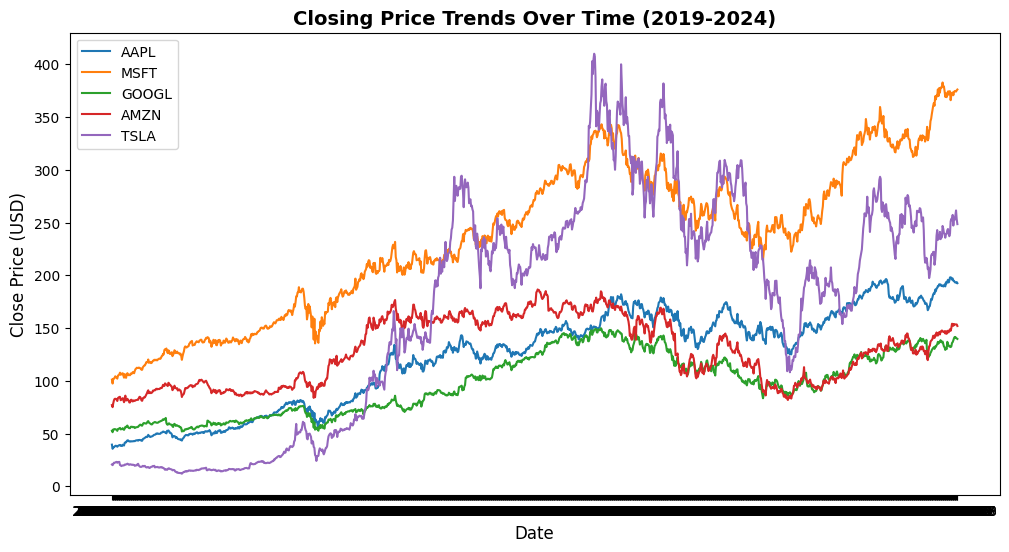

In [ ]:
plt.figure(figsize=(12, 6))
sample_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
subset = data[data["Ticker"].isin(sample_tickers)]

for ticker in sample_tickers:
  ticker_data = subset[subset["Ticker"] == ticker]
  plt.plot(
      ticker_data["Date"], ticker_data["Close"], label=ticker
  )

plt.title(
    "Closing Price Trends Over Time (2019-2024)", fontsize=14, fontweight="bold"
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (USD)", fontsize=12)
plt.legend()
plt.show()

In [ ]:
data["Close_Rolling_Mean_30"] = (
    data.groupby("Ticker")["Close"].rolling(window=30).mean().reset_index(level=0, drop=True)
)

data["Close_Rolling_Std_30"] = (
    data.groupby("Ticker")["Close"].rolling(window=30).std().reset_index(level=0, drop=True)
)
data.head(31)

,Date,Open,High,Low,Close,Volume,Ticker,Close_Rolling_Mean_30,Close_Rolling_Std_30
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,148158800,AAPL,NaN,NaN
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,365248800,AAPL,NaN,NaN
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,234428400,AAPL,NaN,NaN
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,219111200,AAPL,NaN,NaN
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,164101200,AAPL,NaN,NaN
5,2019-01-09,37.822498,38.632500,37.407501,38.327499,180396400,AAPL,NaN,NaN
6,2019-01-10,38.125000,38.492500,37.715000,38.450001,143122800,AAPL,NaN,NaN
7,2019-01-11,38.220001,38.424999,37.877499,38.072498,108092800,AAPL,NaN,NaN
8,2019-01-14,37.712502,37.817501,37.305000,37.500000,129756800,AAPL,NaN,NaN
9,2019-01-15,37.567501,38.347500,37.512501,38.267502,114843600,AAPL,NaN,NaN


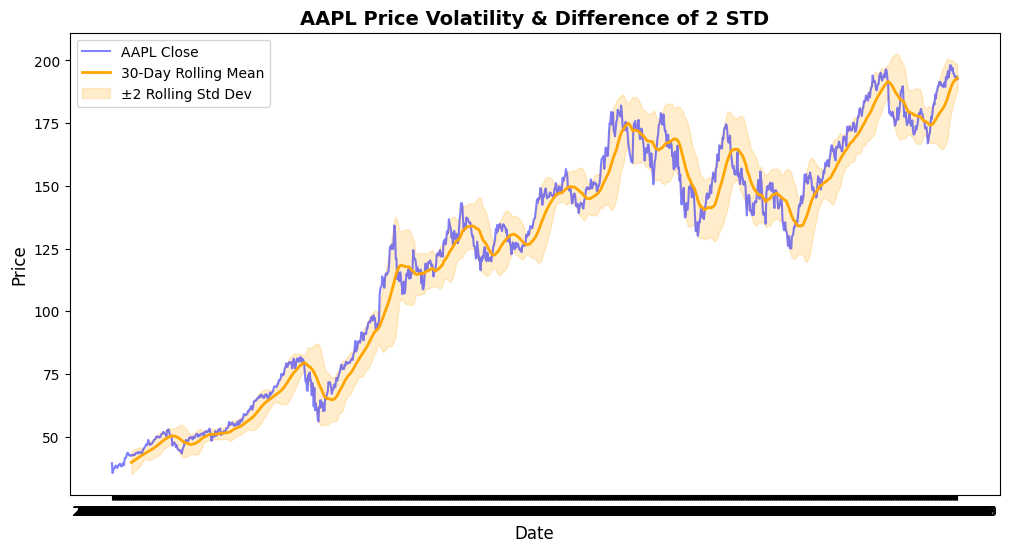

In [ ]:
aapl = data[data["Ticker"] == "AAPL"].copy()
aapl["Rolling_Mean"] = aapl["Close"].rolling(window=30).mean()
aapl["Rolling_Std"] = aapl["Close"].rolling(window=30).std()

plt.figure(figsize=(12, 6))
plt.plot(
    aapl["Date"], aapl["Close"], label="AAPL Close", color="blue", alpha = 0.5
)
plt.plot(
    aapl["Date"],
    aapl["Rolling_Mean"],
    label="30-Day Rolling Mean",
    color="orange",
    lw=2,
)
plt.fill_between(
    aapl["Date"],
    aapl["Rolling_Mean"] - 2 * aapl["Rolling_Std"],
    aapl["Rolling_Mean"] + 2 * aapl["Rolling_Std"],
    color="orange",
    alpha=0.2,
    label="±2 Rolling Std Dev",
)

plt.title(
    "AAPL Price Volatility & Difference of 2 STD",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.show()

MAE: 1.6890011562950797
RMSE: 2.199626522802558


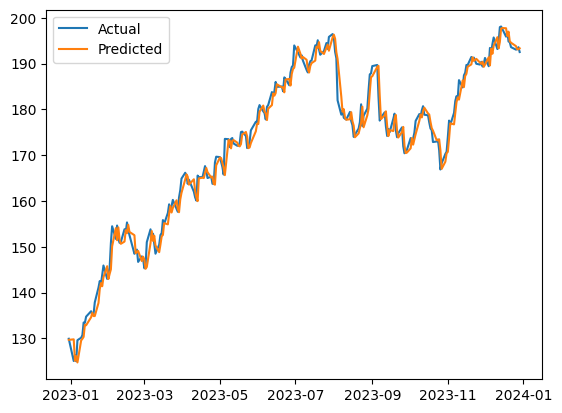

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv"
df = pd.read_csv(url)

df = df[df["Ticker"] == "AAPL"].copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")

df["Column"] = df["Close"]

df["Lag_1"] = df["Column"].shift(1)
df["Lag_7"] = df["Column"].shift(7)
df["Rolling_Mean_7"] = df["Column"].shift(1).rolling(7).mean()

df["Month"] = df.index.month
df["Day_Of_Week"] = df.index.dayofweek
df["Weekend"] = (df.index.dayofweek >= 5).astype(int)

features = [
    "Lag_1",
    "Lag_7",
    "Rolling_Mean_7",
    "Month",
    "Day_Of_Week",
    "Weekend",
]

model_df = df.dropna()
X = model_df[features]
y = model_df["Column"]

split = int(len(model_df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

results = pd.DataFrame(
    {"Actual": y_test, "Predicted": predictions}, index=y_test.index
)

plt.plot(results.index, results["Actual"], label="Actual")
plt.plot(results.index, results["Predicted"], label="Predicted")
plt.legend()
plt.show()

Baseline Random Forest Predictor

Directional Accuracy: 0.4800

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.18      0.24       112
           1       0.52      0.72      0.61       138

    accuracy                           0.48       250
   macro avg       0.43      0.45      0.42       250
weighted avg       0.44      0.48      0.44       250



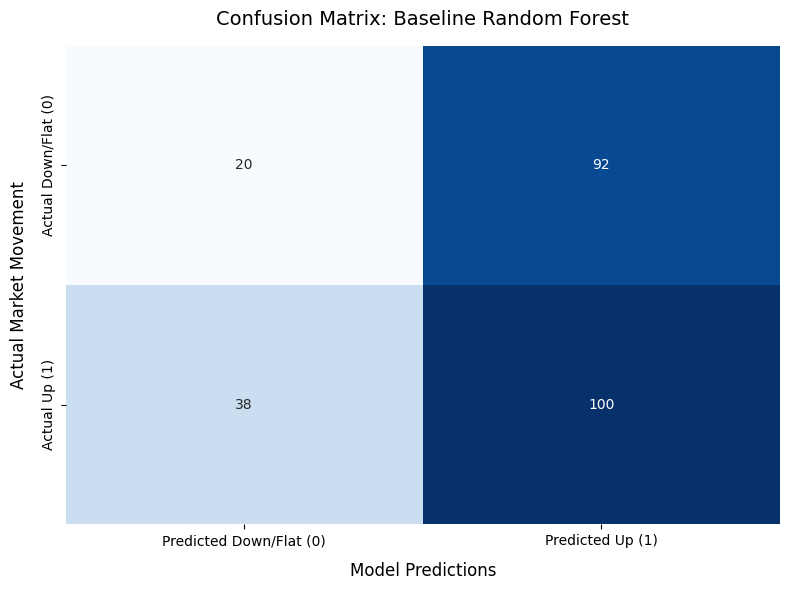

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv"
df = pd.read_csv(url)

df = df[df["Ticker"] == "AAPL"].copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")

df["Column"] = df["Close"]

df["Log_Return"] = np.log(df["Column"] / df["Column"].shift(1))

df["Target"] = (df["Log_Return"].shift(-3) > 0).astype(int)

df["Lag_1"] = df["Log_Return"].shift(1)
df["Lag_7"] = df["Log_Return"].shift(7)
df["Rolling_Volatility"] = df["Log_Return"].shift(1).rolling(7).std()

df["Month"] = df.index.month
df["Day_Of_Week"] = df.index.dayofweek
df["Weekend"] = (df.index.dayofweek >= 5).astype(int)

features = [
    "Lag_1",
    "Lag_7",
    "Rolling_Volatility",
    "Month",
    "Day_Of_Week",
    "Weekend",
]

model_df = df.dropna()
X = model_df[features]
y = model_df["Target"]

split = int(len(model_df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Baseline Random Forest Predictor\n")

accuracy = accuracy_score(y_test, predictions)
print(f"Directional Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down/Flat (0)', 'Predicted Up (1)'],
            yticklabels=['Actual Down/Flat (0)', 'Actual Up (1)'])
plt.title('Confusion Matrix: Baseline Random Forest', fontsize=14, pad=15)
plt.xlabel('Model Predictions', fontsize=12, labelpad=10)
plt.ylabel('Actual Market Movement', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

Gradient Booster 3 day Stock Prediction

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.20      0.27       101
           1       0.59      0.81      0.69       145

    accuracy                           0.56       246
   macro avg       0.51      0.51      0.48       246
weighted avg       0.52      0.56      0.52       246



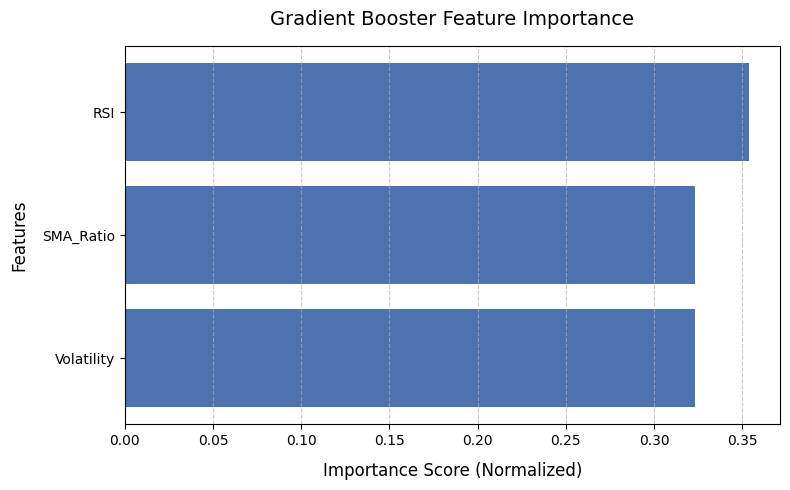

In [ ]:
# Rolling mean + Gradient Booster -> 3 day predictor

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv"
df = pd.read_csv(url)

df = df[df["Ticker"] == "AAPL"].copy()

df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.set_index("Date", inplace=True)

df["Column"] = df["Close"]

df["SMA_10"] = df["Column"].rolling(window=10).mean()
df["SMA_30"] = df["Column"].rolling(window=30).mean()
df["SMA_Ratio"] = df["SMA_10"] / df["SMA_30"]

delta = df["Column"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

df["Volatility"] = df["Column"].pct_change().rolling(window=10).std()

df["Target"] = (df["Column"].shift(-3) > df["Column"]).astype(int)

features = ["SMA_Ratio", "RSI", "Volatility"]
model_df = df.dropna(subset=features + ["Target"]).copy()

X = model_df[features]
y = model_df["Target"]

split = int(len(model_df) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Gradient Booster 3 day Stock Prediction")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='#4C72B0')
plt.yticks(range(len(sorted_idx)), np.array(features)[sorted_idx])
plt.title('Gradient Booster Feature Importance', fontsize=14, pad=15)
plt.xlabel('Importance Score (Normalized)', fontsize=12, labelpad=10)
plt.ylabel('Features', fontsize=12, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# 3 day predictor -> Random Forest

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report

url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv"
df = pd.read_csv(url)

df = df[df["Ticker"] == "AAPL"].copy()

df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.set_index("Date", inplace=True)

df["Column"] = df["Close"]

df["Rolling_Mean_3"] = df["Column"].rolling(window=3).mean()
df["Rolling_Mean_10"] = df["Column"].rolling(window=10).mean()
df["Rolling_Mean_30"] = df["Column"].rolling(window=30).mean()

df["Rolling_Volatility"] = df["Column"].pct_change().rolling(window=10).std()

df["Target"] = (df["Column"].shift(-3) > df["Column"]).astype(int)

features = ["Rolling_Mean_3", "Rolling_Mean_10", "Rolling_Mean_30", "Rolling_Volatility"]
model_df = df.dropna(subset=features + ["Target"]).copy()

X = model_df[features]
y = model_df["Target"]

tscv = TimeSeriesSplit(n_splits=5)

splits = list(tscv.split(X))
train_index, test_index = splits[0]

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

acc = accuracy_score(y_test, predictions)
print("Random Forest 3 day Stock Prediction")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Random Forest 3 day Stock Prediction

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        68
           1       0.66      0.98      0.79       136

    accuracy                           0.65       204
   macro avg       0.33      0.49      0.39       204
weighted avg       0.44      0.65      0.53       204



In [ ]:
# 3 day predictor -> Random Forest (NEW VERSION)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report

url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv"
df = pd.read_csv(url)

df = df[df["Ticker"] == "AAPL"].copy()

df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.set_index("Date", inplace=True)

df["Column"] = df["Close"]

df["Return_1d"] = df["Column"].pct_change()

df["SMA_10_Ratio"] = df["Column"] / df["Column"].rolling(window=10).mean()
df["SMA_30_Ratio"] = df["Column"] / df["Column"].rolling(window=30).mean()
df["Rolling_Volatility"] = df["Column"].pct_change().rolling(window=10).std()

df["Target"] = (df["Column"].shift(-3) > df["Column"]).astype(int)

features = ["Return_1d", "SMA_10_Ratio", "SMA_30_Ratio", "Rolling_Volatility"]
model_df = df.dropna(subset=features + ["Target"]).copy()

X = model_df[features]
y = model_df["Target"]

tscv = TimeSeriesSplit(n_splits=5)

splits = list(tscv.split(X))
train_index, test_index = splits[-1]

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

acc = accuracy_score(y_test, predictions)
print("Random Forest 3 day Stock Prediction")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Random Forest 3 day Stock Prediction

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.20      0.28        84
           1       0.60      0.83      0.70       120

    accuracy                           0.57       204
   macro avg       0.53      0.52      0.49       204
weighted avg       0.54      0.57      0.53       204



=== 5-Fold Cross Validation Results ===
Fold 1 (Train Size: 206, Test Size: 204) -> Accuracy: 0.6029
Fold 2 (Train Size: 410, Test Size: 204) -> Accuracy: 0.5441
Fold 3 (Train Size: 614, Test Size: 204) -> Accuracy: 0.5049
Fold 4 (Train Size: 818, Test Size: 204) -> Accuracy: 0.5000
Fold 5 (Train Size: 1022, Test Size: 204) -> Accuracy: 0.5980

=== Final Evaluation ===
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.23      0.32        83
           1       0.62      0.85      0.72       121

    accuracy                           0.60       204
   macro avg       0.57      0.54      0.52       204
weighted avg       0.57      0.60      0.55       204



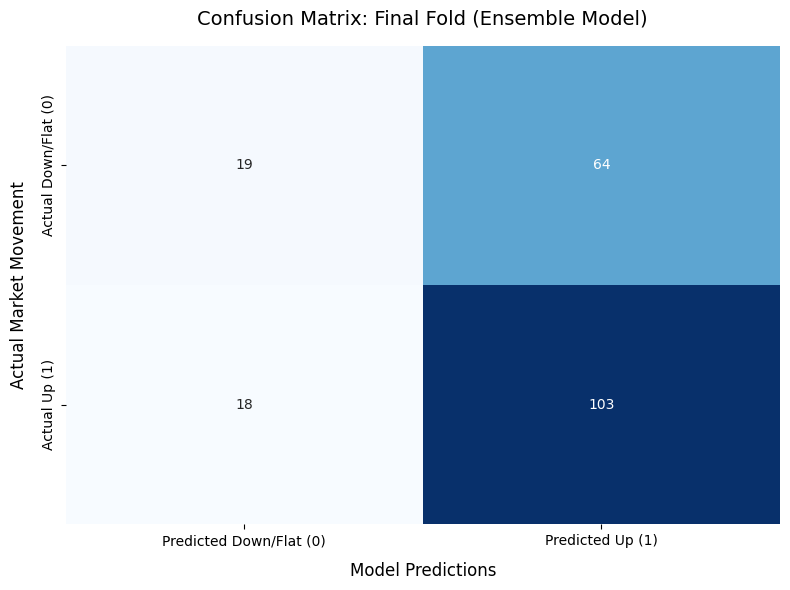

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv"
df = pd.read_csv(url)

df = df[df["Ticker"] == "AAPL"].copy()
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.set_index("Date", inplace=True)

df["Column"] = df["Close"]

df["Return_1d"] = df["Column"].pct_change()
df["SMA_10_Ratio"] = df["Column"] / df["Column"].rolling(window=10).mean()
df["SMA_30_Ratio"] = df["Column"] / df["Column"].rolling(window=30).mean()
df["Rolling_Volatility"] = df["Column"].pct_change().rolling(window=10).std()

df["Target"] = (df["Column"].shift(-3) > df["Column"]).astype(int)

df = df.iloc[:-3].copy()

features = ["Return_1d", "SMA_10_Ratio", "SMA_30_Ratio", "Rolling_Volatility"]
model_df = df.dropna(subset=features + ["Target"]).copy()

X = model_df[features]
y = model_df["Target"]

tscv = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('lr', lr_model)],
    voting='soft'
)

print("=== 5-Fold Cross Validation Results ===")
fold = 1
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ensemble_model.fit(X_train_scaled, y_train)
    predictions = ensemble_model.predict(X_test_scaled)

    acc = accuracy_score(y_test, predictions)
    print(f"Fold {fold} (Train Size: {len(X_train)}, Test Size: {len(X_test)}) -> Accuracy: {acc:.4f}")
    fold += 1

print("\n=== Final Evaluation ===")
print("Classification Report:")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down/Flat (0)', 'Predicted Up (1)'],
            yticklabels=['Actual Down/Flat (0)', 'Actual Up (1)'])
plt.title('Confusion Matrix: Final Fold (Ensemble Model)', fontsize=14, pad=15)
plt.xlabel('Model Predictions', fontsize=12, labelpad=10)
plt.ylabel('Actual Market Movement', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()